#Linear Regression Practical Implementaton

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [23]:
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1,as_frame=True,parser='pandas')

In [51]:
boston

{'data':         CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  \
 0    0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0   
 1    0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0   
 2    0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0   
 3    0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0   
 4    0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0   
 ..       ...   ...    ...  ...    ...    ...   ...     ...  ..    ...   
 501  0.06263   0.0  11.93    0  0.573  6.593  69.1  2.4786   1  273.0   
 502  0.04527   0.0  11.93    0  0.573  6.120  76.7  2.2875   1  273.0   
 503  0.06076   0.0  11.93    0  0.573  6.976  91.0  2.1675   1  273.0   
 504  0.10959   0.0  11.93    0  0.573  6.794  89.3  2.3889   1  273.0   
 505  0.04741   0.0  11.93    0  0.573  6.030  80.8  2.5050   1  273.0   
 
      PTRATIO       B  LSTAT  
 0       15.3  396.90   4.98  
 1       17.8  396.90   9.14  
 2       

In [25]:
df = boston.frame

In [26]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [27]:
df['price'] = boston.target
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,36.2


In [8]:
# Dividing the dataset into dependent and independent feature

In [28]:
x = df.iloc[:, :-1]

In [10]:
x.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [29]:
y = df.iloc[:,-1]

In [30]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: price, dtype: float64

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X = x.astype(float)
Y = y.astype(float)

lin_reg = LinearRegression()
mse = cross_val_score(lin_reg, X, Y, scoring = 'neg_mean_squared_error', cv=5)
print(mse)

[-3.68135089e-28 -6.04314316e-28 -1.06347823e-28 -8.99879409e-28
 -3.93292462e-27]


In [34]:
mse_mean = np.mean(mse)

print("MSE Score per fold", mse)
print("Average Negative MSE", mse_mean)

MSE Score per fold [-3.68135089e-28 -6.04314316e-28 -1.06347823e-28 -8.99879409e-28
 -3.93292462e-27]
Average Negative MSE -1.1823202518326814e-27


In [45]:
from sklearn.model_selection import train_test_split

X_Train, X_Test, Y_Train, Y_Test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

lin_reg.fit(X_Train,Y_Train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
prediction = lin_reg.predict(X_Test)
print(prediction)

[23.6 32.4 13.6 22.8 16.1 20.  17.8 14.  19.6 16.8 21.5 18.9  7.  21.2
 18.5 29.8 18.8 10.2 50.  14.1 25.2 29.1 12.7 22.4 14.2 13.8 20.3 14.9
 21.7 18.3 23.1 23.8 15.  20.8 19.1 19.4 34.7 19.5 24.4 23.4 19.7 28.2
 50.  17.4 22.6 15.1 13.1 24.2 19.9 24.  18.9 35.4 15.2 26.5 43.5 21.2
 18.4 28.5 23.9 18.5 25.  35.4 31.5 20.2 24.1 20.  13.1 24.8 30.8 12.7
 20.  23.7 10.8 20.6 20.8  5.  20.1 48.5 10.9  7.  20.9 17.2 20.9  9.7
 19.4 29.  16.4 25.  25.  17.1 23.2 10.4 19.6 17.2 27.5 23.  50.  17.9
  9.6 17.2 22.5 21.4]


In [47]:
#Compare few Actual value and predicted value
import pandas as pd
comparison_df = pd.DataFrame({'Actual': Y_Test, 'Predicted': prediction})
print(comparison_df.head())

     Actual  Predicted
173    23.6       23.6
274    32.4       32.4
491    13.6       13.6
72     22.8       22.8
452    16.1       16.1


In [54]:
from sklearn import metrics
import numpy as np

#1. R-squared Score (Best possible score is 1.0)
r2 = metrics.r2_score(Y_Test, prediction)

#2. Mean Absolute Error (Average error in 'price' units)
mae = metrics.mean_absolute_error(Y_Test, prediction)

#3. Root Mean Squared Error (Standard deviation of prediction errors) 
rmse = np.sqrt(metrics.mean_squared_error (Y_Test, prediction))

print (f"R-squared Score: {r2:.4f}")
print (f"Mean Absolute Error (MAE): {mae:.4f}")
print (f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared Score: 1.0000
Mean Absolute Error (MAE): 0.0000
Root Mean Squared Error (RMSE): 0.0000


# Ridge Regression

In [55]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
params = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2,1,5,10,20]}
ridge_regressor = GridSearchCV (ridge, params, scoring = 'neg_mean_squared_error', cv = 5)
ridge_regressor.fit(X,Y)

,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1e-15


In [58]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 1e-15}
-1.025755635967603e-28


# Lasso Regression

In [60]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso = Lasso()
params = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2,1,5,10,20]}
lasso_regressor = GridSearchCV (lasso, params, scoring = 'neg_mean_squared_error', cv = 5)
lasso_regressor.fit(X,Y)

,estimator,Lasso()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1e-08


In [61]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 1e-08}
-1.06260858893211e-07


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Ensure data is numeric
X = X.astype (float)
Y=  Y.astype(float)

# 1. Scale the features (Essential for Ridge and Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 2. Split into Training and Testing sets
X_Train, X_Test, Y_Train, Y_Test = train_test_split (X_scaled, Y, test_size=0.2, random_state=42)

In [65]:
from sklearn.linear_model import LinearRegression

# Initialize and Train
lin_reg = LinearRegression()
lin_reg.fit(X_Train, Y_Train)

# Predict and Calculate Accuracy
lin_pred = lin_reg.predict(X_Test)
lin_acc = r2_score (Y_Test, lin_pred) * 100

print (f"Linear Regression Accuracy: {lin_acc:.2f}%")
          

Linear Regression Accuracy: 100.00%


In [69]:
from sklearn.linear_model import Ridge

# Alpha is the penalty strength (higher alpha = more restriction)
ridge_reg =  Ridge (alpha=10.0)
ridge_reg.fit(X_Train, Y_Train)

# Predict and Calculate Accuracy
ridge_pred = ridge_reg.predict(X_Test)
ridge_acc  = r2_score (Y_Test, ridge_pred) * 100

print (f"Ridge Regression Accuracy: {ridge_acc:.2f}%")
          

Ridge Regression Accuracy: 99.76%


In [72]:
from sklearn.linear_model import Lasso

# Alpha=0.1 is a common starting point for Lasso
lasso_reg = Lasso (alpha=0.1)
lasso_reg.fit(X_Train, Y_Train)

# Predict and Calculate Accuracy
lasso_pred = lasso_reg.predict(X_Test)
lasso_acc  = r2_score (Y_Test, lasso_pred) * 100

print (f"Lasso Regression Accuracy: {lasso_acc:.2f}%")
          

Lasso Regression Accuracy: 99.99%


# Logistic Regression

In [73]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix


In [74]:
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [77]:
X = pd.DataFrame(data.data, columns = data.feature_names)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [78]:
y = data.target
y
# y (target) this is our dependent attribute. 0 means 
# cancer Malignant and 1 means no cancer Benign

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

# Training & Testing Data split

In [80]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size =0.2, random_state=42)

# Feature Scaling

In [81]:
scaler = StandardScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test  = scaler.transform(X_Test)

In [82]:
model = LogisticRegression()
model.fit(X_Train, Y_Train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Prediction

In [84]:
Y_Pred = model.predict(X_Test)
Y_Pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [85]:
Y_Test

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

# Accuracy

In [86]:
print(f"Accuracy Score: {accuracy_score(Y_Test, Y_Pred):.4f}")
print(classification_report(Y_Test, Y_Pred))

Accuracy Score: 0.9737
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



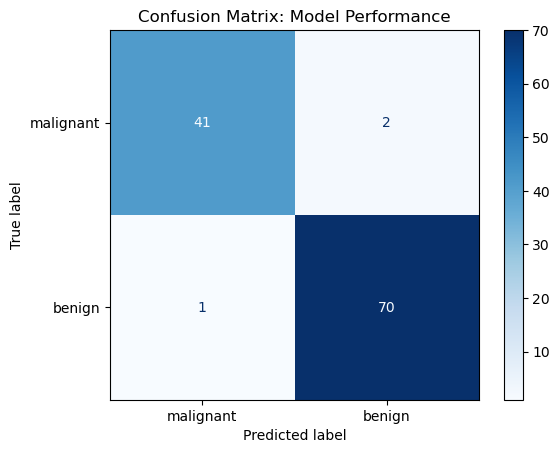

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm= confusion_matrix(Y_Test,Y_Pred)

disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= data.target_names)

disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix: Model Performance")
plt.show()


# Naive Bayes

In [ ]:
#Is code ka main maqsad hai ek Machine Learning model banana
#jo phoolon (Iris flowers) ki dimensions dekh kar
#unka sahi naam (Species) predict kar sake.

#Hum Gaussian Naive Bayes algorithm ka use kar
#rahe hain, jo probability (sambhavna) par kaam karta hai.

In [88]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#sklearn: Yeh ML ki main Library hai. Isse humne dataset,
#data split karne ka tool, aur Naive Bayes algorithm Liya hai.

#pandas: Data ko table (DataFrame) format mein dekhne ke liye.

#seaborn/matplotlib: Result ko graph (Confusion Matrix) ke roop mein dikhane ke liye.
          

In [89]:
iris = datasets.load_iris()

In [91]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [92]:
X = iris.data # Feature : Length & Width
y = iris.target # name of flower

In [93]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [94]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [97]:
# Convert to DataFrame just for a cleaner Look at the data
df = pd.DataFrame(X, columns=iris.feature_names)
df ['species'] = y
print("First 5 rows of the dataset: ")
print(df.head())

First 5 rows of the dataset: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Hum saara data model ko nahi sikhate. 80% data (Train) hum model ko
#padhane ke liye rakhte hain, aur 20% data (Test)
#hum model ka exam Lene ke liye chhupa kar rakhte hain.

# 4. Model training   

In [100]:
model = GaussianNB()
model.fit(X_train, y_train)

#GaussianNB(): Humne Naive Bayes ka "dimag" (object) banaya.

#.fit(): Yahan asli Training ho rahi hai.
# Model X_train aur y_train ke beech ka pattern samajh raha hai.
      

,priors,None
,var_smoothing,1e-09


# Prediction

In [101]:
y_pred = model.predict(X_test)

In [102]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [103]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

# 6 Accuracy

In [108]:
accuracy = accuracy_score (y_test, y_pred)
print (f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report: ")
print (classification_report (y_test, y_pred, target_names=iris.target_names))
       


Model Accuracy: 100.00%

Classification Report: 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Confusion Matrix

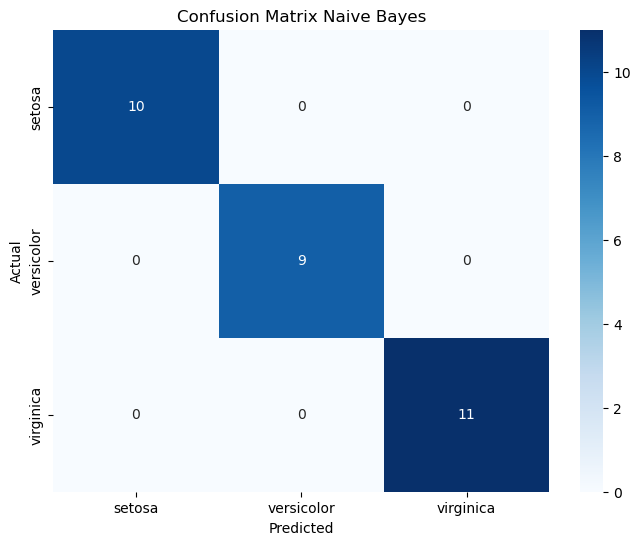

In [111]:
cm = confusion_matrix (y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Naive Bayes')
plt.show()
          

# KNN Algorithmns

In [114]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [118]:
iris = datasets.load_iris()
X = iris.data # Feature : Length & Width
y = iris.target # name of flower

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [120]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [121]:
# We'll use k=3 for this example
knn = KNeighborsClassifier (n_neighbors=3)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [122]:
y_pred = knn.predict(X_test)

In [123]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [124]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [128]:
accuracy = accuracy_score(y_test, y_pred)
print (f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


# Decision Tree Algorithm

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [132]:
iris = load_iris()
X = iris.data
y = iris.target

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [135]:
# criterion= 'gini' (Default) ya 'entropy' use kar sakte hain
# max_depth=3 rakha hai taaki overfitting na ho (Pruning)
clf = DecisionTreeClassifier (criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [136]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [137]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [139]:
print (f"Accuracy Score: {accuracy_score (y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("\nDetailed Report: \n", classification_report (y_test, y_pred))
          

Accuracy Score: 100.00%

Confusion Matrix: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Detailed Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Decision tree visualisation

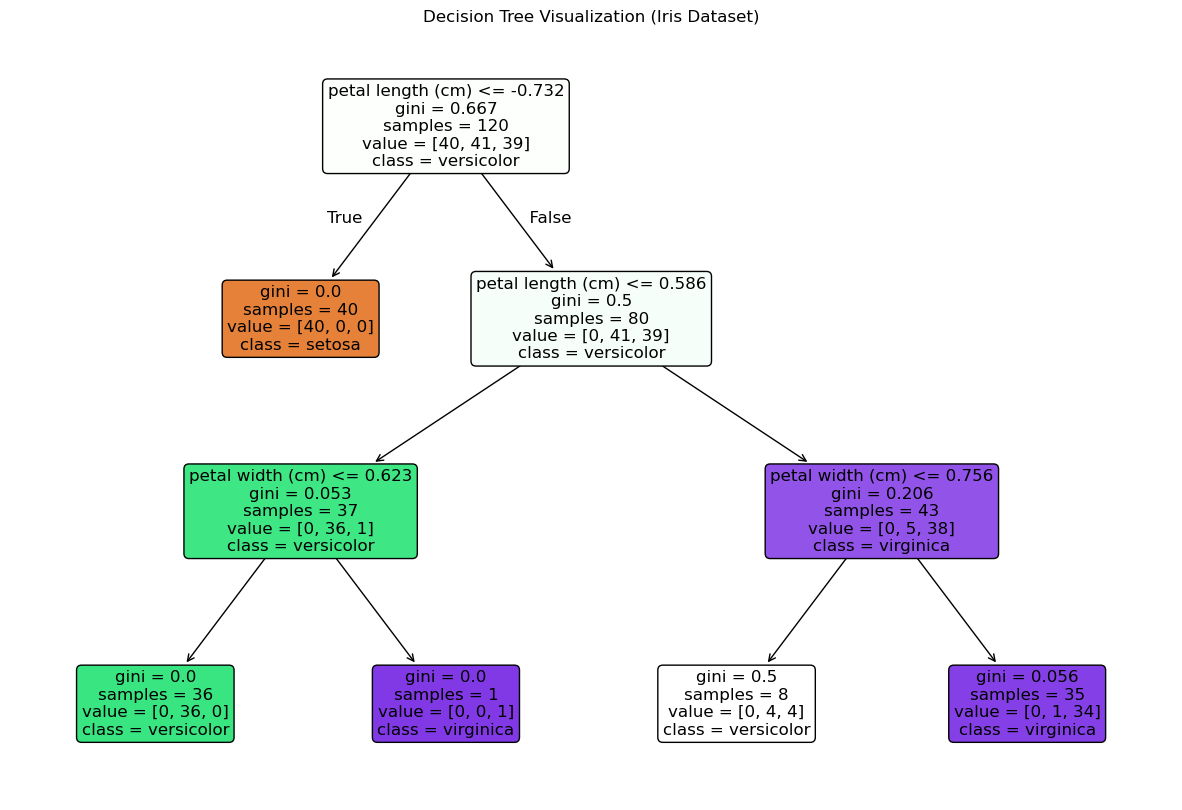

In [141]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10)) # Diagram ka size bada karne ke liye
plot_tree (clf,
         feature_names=iris.feature_names,  # Features ke naam (e.g. Petal Length)
         class_names=iris.target_names,    # Classes ke naam (e.g. Setosa)
         filled=True,                      # Nodes mein color bharne ke liye
         rounded=True,                     # Boxes ke corners round karne ke liye
          fontsize=12)                     # Text ka size
plt.title("Decision Tree Visualization (Iris Dataset)")
plt.show()      

# Random Forest Algorithm

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [143]:
# 1. Dataset Load karna (Breast Cancer dataset Diagnosis ke liye)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [145]:
# 3. Random Forest Classifier banana

#n_estimators: Kitne trees banane hain (Forest mein kitne ped honge)
#max_depth: Ek tree kitna gehra ja sakta hai
# random_state: Har baar same result milne ke liye
rf_model = RandomForestClassifier (n_estimators=100, max_depth=5, random_state=42)

#Tip: Zyadatar cases mein n_estimators jitna zyada hoga, model utna stable hoga, 
#     Lekin calculations mein time bhi utna hi zyada Lagega
          

In [146]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [147]:
y_pred = rf_model.predict(X_test)

In [148]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [149]:
y_test

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [152]:
print (f"Model Accuracy: {accuracy_score (y_test, y_pred)  * 100:.2f}%")
print("\nClassification Report: \n", classification_report(y_test, y_pred))
     

Model Accuracy: 96.49%

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



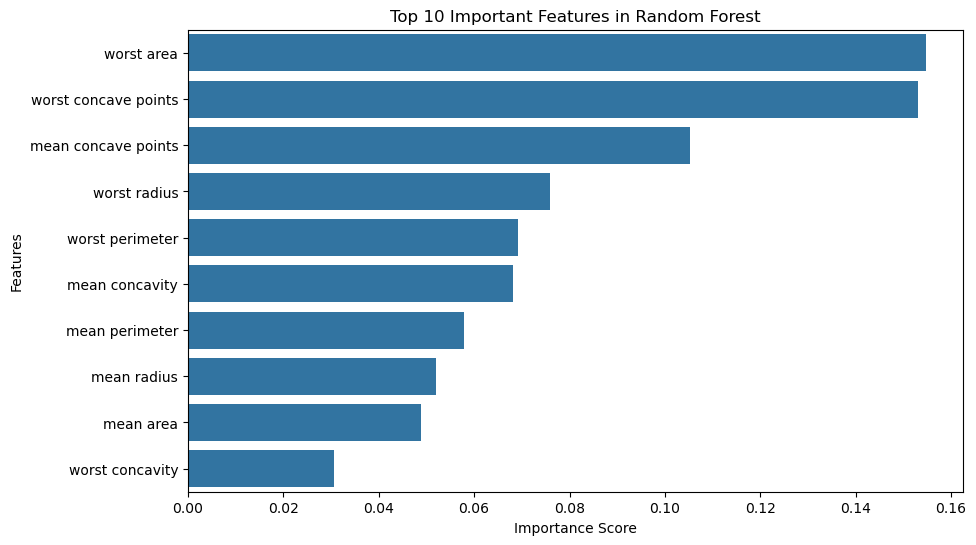

In [158]:
# Visualization: Feature Importance
# Random Forest batata hai ki kaunsa feature (column) sabse important tha
importances = rf_model.feature_importances_
feature_imp = pd.Series (importances, index=data.feature_names).sort_values (ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp[:10], y=feature_imp.index [:10]) # Top 10 features
plt.title("Top 10 Important Features in Random Forest")                                                         
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Ada Boost Algorithmn

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [161]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [165]:
 # 3. Base Learner define karna (Decision Stump: depth=1)
# AdaBoost by default DecisionTreeClassifier(max_depth=1) hi use karta hai
base_estimator = DecisionTreeClassifier(max_depth=1)

In [167]:
# 4. AdaBoost Classifier initialize aur train karna
#n_estimators: kitne stumps banane hain
# Learning_rate: har stump ka contribution kitna hoga
ada_model = AdaBoostClassifier(estimator=base_estimator,
                                        n_estimators=100,
                                        learning_rate=1.0,
                                        random_state=42)

In [170]:
ada_model.fit(X_train,y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [171]:
y_pred = ada_model.predict(X_test)

In [172]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [173]:
y_test

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [175]:
# 6. Model Evaluation
print (f"AdaBoost Accuracy Score: {accuracy_score (y_test, y_pred) * 100: .2f}%")
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("\nClassification Report: \n", classification_report (y_test, y_pred))

AdaBoost Accuracy Score:  97.37%

Confusion Matrix: 
 [[41  2]
 [ 1 70]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# XgBoost Algorithm

In [177]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 7.2 MB/s eta 0:00:15
   - -------------------------------------- 2.6/101.7 MB 6.5 MB/s eta 0:00:16
   -- ------------------------------------- 5.2/101.7 MB 8.5 MB/s eta 0:00:12
   -- ------------------------------------- 7.6/101.7 MB 9.3 MB/s eta 0:00:11
   --- ------------------------------------ 10.0/101.7 MB 9.8 MB/s eta 0:00:10
   ---- ----------------------------------- 12.6/101.7 MB 10.2 MB/s eta 0:00:09
   ----- ---------------------------------- 15.2/101.7 MB 10.4 MB/s eta 0:00:09
   ------ --------------------------------- 17.6/101.7 MB 10.6 MB/s eta 0:00:08
   ------- -------------------------------- 19.9/101.7 MB 10.7 MB/s eta 0:00:08
   -------- ------------------------------- 22.3/101.7 MB 10.8 MB/s eta 0:00:08
   --------- ------------------------------ 24.9/101.7 MB 10.9 MB/s eta 0:00:08
   ---------- ----------------------------- 27.3/101.7 MB 

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier  # AdaBoost ki jagah XGBoost import karo

In [179]:
# 1. Data load karna (same as AdaBoost)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Train-Test Split (same as AdaBoost)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [184]:
# 3. XGBoost Classifier initialize karna
# n_estimators  : kitne trees banane hain (AdaBoost ke stumps jaisa)
# learning_rate : har tree ka contribution kitna hoga (AdaBoost jaisa hi)
# max_depth     : AdaBoost mein depth=1 tha, XGBoost mein depth=3-6 hota hai
# use_label_encoder / eval_metric: XGBoost ke liye zaroori settings
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=1.0,
    max_depth=3,
    random_state=42,
    # use_label_encoder=False,
    eval_metric='logloss'
)

In [186]:
# 4. Model train karna (same as AdaBoost)
xgb_model.fit(X_train, y_train)

# 5. Prediction karna (same as AdaBoost)
y_pred = xgb_model.predict(X_test)

# 6. Model evaluate karna
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315

Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# Support Vector Machine Algo (SVM)

In [187]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42)

# kernel='rbf' = RBF kernel (handles non-linear data)
# C = how much to penalise mistakes (higher C = stricter boundary)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9473684210526315


# UnSupervised

# K-Mean Clustering Algo

C:\Users\Shailesh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


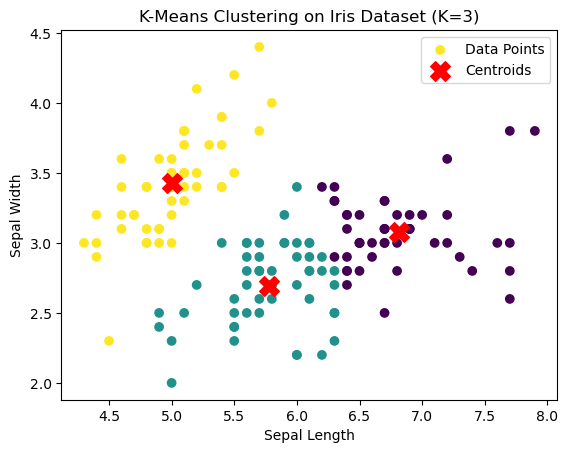

In [188]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

# ============================================================
# STEP 1: Load the Data
# We are using the Iris dataset — it contains measurements
# (length & width) of 3 types of flowers (150 samples total)
# ============================================================
iris = load_iris()
# We only take the first 2 features (Sepal Length & Sepal Width)
# so that we can easily plot the clusters in a 2D graph
X = iris.data[:, :2]
 

# We already know Iris has 3 types of flowers,
# so we set n_clusters=3 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# predict(X) tells us which cluster (0, 1, or 2) each
# data point (flower) was assigned to
y_kmeans = kmeans.predict(X)
 
# cluster_centers_ gives us the centroid of each of the 3 clusters
centers = kmeans.cluster_centers_
 
# Plot all data points, colored by which cluster they belong to
# cmap='viridis' gives each cluster a different color
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', label='Data Points')
 
# Plot the centroids as big red 'X' markers (s=200 = large size)
# These represent the center of each cluster
plt.scatter(centers[:, 0], centers[:, 1],
            c='red', s=200, marker='X', label='Centroids')
 
# Label the axes
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
 
# Add a title and legend, then display the plot
plt.title('K-Means Clustering on Iris Dataset (K=3)')
plt.legend()
plt.show()

#  Hierarchical Clustering on Dummy Data

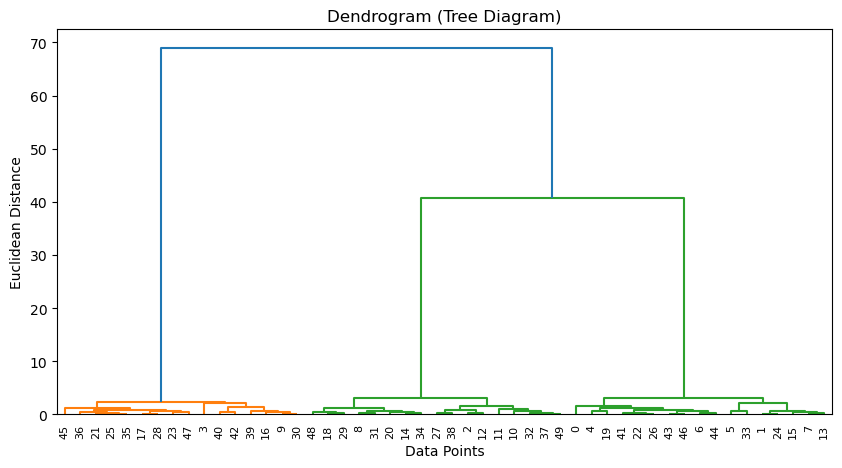

In [190]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch          # For drawing the dendrogram
from sklearn.cluster import AgglomerativeClustering  # For the actual clustering model
from sklearn.datasets import make_blobs        # For generating fake/dummy data

# ============================================================
# STEP 1: Create Dummy Data
# make_blobs generates artificial data points grouped into blobs
# - n_samples=50   : create 50 data points total
# - centers=3      : spread them around 3 center points (3 natural groups)
# - cluster_std=0.6: how spread out each blob is (smaller = tighter clusters)
# - random_state=42: ensures we get the same data every time we run
# ============================================================
X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.6, random_state=42)
# Note: we use _ to discard the true labels — we pretend we don't know them
 
 
# ============================================================
# STEP 2: Draw the Dendrogram
# The dendrogram is a tree diagram that shows HOW the algorithm
# merged points step by step, and helps us visually decide
# how many clusters (K) we should use.
#
# sch.linkage(X, method='ward') calculates the distances between
# all points using the "Ward" method — which minimizes variance
# when merging clusters (most commonly used linkage method)
# ============================================================
plt.figure(figsize=(10, 5))  # Set the figure size (width=10, height=5)
 
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
 
plt.title('Dendrogram (Tree Diagram)')  # Title of the plot
plt.xlabel('Data Points')               # X-axis = individual data points
plt.ylabel('Euclidean Distance')        # Y-axis = distance at which clusters merged
 
plt.show()
# Look at the dendrogram: find the longest vertical line that no
# horizontal line crosses — that's where you should "cut" the tree.
# The number of vertical lines you cut through = number of clusters.

C:\Users\Shailesh\AppData\Local\Temp\ipykernel_15320\2064347867.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


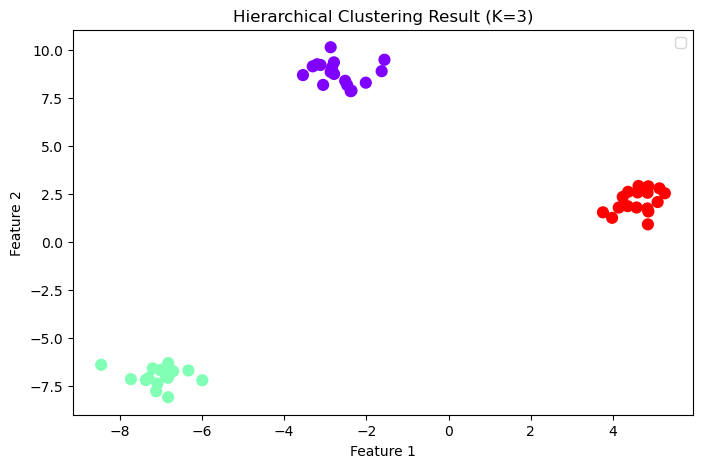

In [195]:
# ============================================================
# STEP 3: Apply Agglomerative (Hierarchical) Clustering
# Now that we've decided K=3 from the dendrogram, we train the model.
#
# AgglomerativeClustering works bottom-up:
#   - Starts with every point as its own cluster
#   - Keeps merging the 2 closest clusters
#   - Stops when we reach n_clusters
#
# - n_clusters=3    : we want 3 final groups (decided from dendrogram)
# - linkage='ward'  : same Ward method used above for consistency
# ============================================================
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
 
# fit_predict trains the model AND returns which cluster each point belongs to
y_pred = model.fit_predict(X)
 
 
# ============================================================
# STEP 4: Visualize the Clusters
# Plot each of the 3 clusters in a different color
# ============================================================
plt.figure(figsize=(8, 5))
 
# Plot each cluster separately so they get different colors in the legend
#plt.scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], s=60, label='Cluster 1', c='red')
#plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], s=60, label='Cluster 2', c='blue')
#plt.scatter(X[y_pred == 2, 0], X[y_pred == 2, 1], s=60, label='Cluster 3', c='green')
plt.scatter(X[:, 0], X[:, 1], s=60, c =y_pred, cmap='rainbow')
 
plt.title('Hierarchical Clustering Result (K=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# DBSCAN Clustering

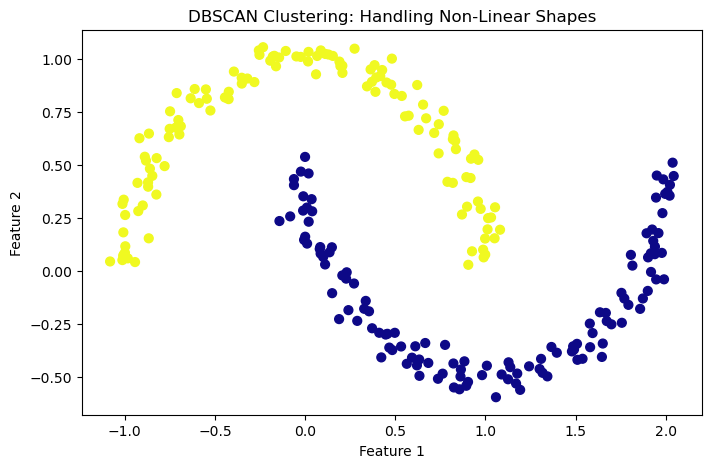

In [196]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# 1. Generate moon-shaped data
X, _ = make_moons(n_samples=250, noise=0.05, random_state=42)

# 2. Create DBSCAN model
# eps: radius to search for neighbors
# min_samples: minimum points needed to form a dense cluster
dbscan = DBSCAN(eps=0.2, min_samples=5)

# 3. Fit model and predict cluster labels
y_pred = dbscan.fit_predict(X)

# 4. Visualize the result
# Note: cluster label -1 means Noise (Outliers)
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='plasma', s=40)
plt.title("DBSCAN Clustering: Handling Non-Linear Shapes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# PCA (Principal Component Analysis) 

Variance explained by each PC: [0.72962445 0.22850762]
Total variance kept: 0.9581320720000164


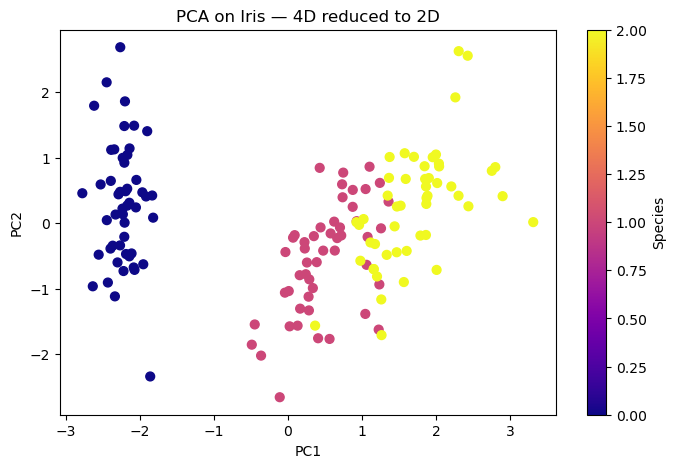

In [197]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Load data (4 features → we'll reduce to 2)
data = load_iris()
X = data.data          # shape: (150, 4)
y = data.target

# 2. Always scale first — PCA is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA — reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)   # shape: (150, 2)

# 4. How much info did we keep?
print("Variance explained by each PC:", pca.explained_variance_ratio_)
print("Total variance kept:", sum(pca.explained_variance_ratio_))

# 5. Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', s=40)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA on Iris — 4D reduced to 2D")
plt.colorbar(label="Species")
plt.show()

# PCA (Principal Component Analysis)

PC1 variance: 72.96 %
PC2 variance: 22.85 %
Total kept  : 95.81 %


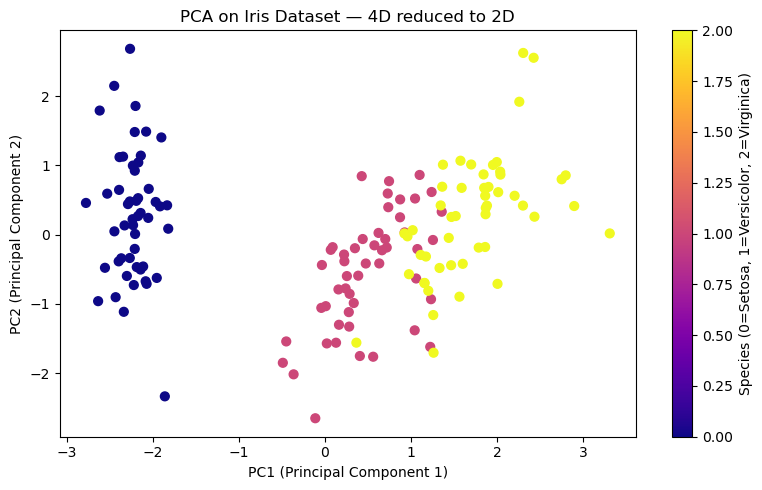

In [198]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Load data (Iris has 4 features)
data = load_iris()
X = data.data        # shape: (150, 4)
y = data.target      # 3 species: 0, 1, 2

# 2. Scale the data — IMPORTANT! PCA is affected by scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA — reduce 4D → 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)   # shape: (150, 2)

# 4. Check how much information is kept
print("PC1 variance:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 variance:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Total kept  :", round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

# 5. Visualize the result
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', s=40)
plt.xlabel("PC1 (Principal Component 1)")
plt.ylabel("PC2 (Principal Component 2)")
plt.title("PCA on Iris Dataset — 4D reduced to 2D")
plt.colorbar(scatter, label="Species (0=Setosa, 1=Versicolor, 2=Virginica)")
plt.tight_layout()
plt.show()

# LDA — Linear Discriminant Analysis

Variance explained: [0.9912126 0.0087874]


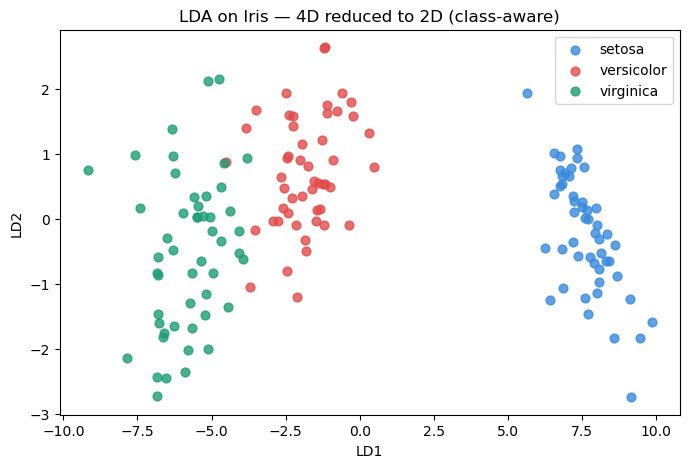

Accuracy: 1.0


In [203]:
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load data
data = load_iris()
X = data.data       # 4 features
y = data.target     # 3 classes — LDA NEEDS these labels (unlike PCA)

# 2. Scale
X = StandardScaler().fit_transform(X)

# 3. Apply LDA — max components = n_classes - 1 = 2
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)   

# 4. How much variance explained?
print("Variance explained:", lda.explained_variance_ratio_)

# 5. Visualize
plt.figure(figsize=(8, 5))
colors = ['#378ADD', '#E24B4A', '#1D9E75']
for i, name in enumerate(data.target_names):
    plt.scatter(X_lda[y==i, 0], X_lda[y==i, 1],
                label=name, color=colors[i], s=40, alpha=0.8)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA on Iris — 4D reduced to 2D (class-aware)")
plt.legend()
plt.show()

# 6. Use LDA for classification directly
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                test_size=0.3, random_state=42)
lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, lda_clf.predict(X_test)))